## DDIM inversion (initalise with MCPL pretrained)

In [1]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from torchvision import transforms
from edit_modules.clip import CLIPTextModel
from edit_modules.embed_manager import EmbeddingManager,Embed_control_manager
from diffusers.models.modeling_utils import load_state_dict
from torchvision import transforms as tfms
from PIL import Image
from transformers import CLIPTokenizer
import torch


from diffusers import StableDiffusionCausalControlNetPipeline, Causal_ControlNetModel, UniPCMultistepScheduler,StableDiffusionPipeline
from causal_modules.ddim_modules import *
size = 256

image_transforms = transforms.Compose(
        [
            transforms.Pad(padding=6),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ]
        )
original_transforms = transforms.Compose(
        [
            transforms.Pad(padding=6),
            transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
        ]
        )

conditioning_image_transforms = transforms.Compose(
            [
                transforms.Resize((size,size), interpolation=transforms.InterpolationMode.BILINEAR),
                transforms.ToTensor(),
                #transforms.Normalize([0.5], [0.5]),
            ]
        )
        

In [3]:
'''Load pipeline'''


base_model_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce"


controlnet_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_ADNI_all/2025-05-06T14-33-14-controlnet_textcond_contrastgeneration_text_global_after/controlnet-steps-100000.safetensors"
mcpl_embedding_path = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_ADNI_all/2025-05-06T14-33-14-controlnet_textcond_contrastgeneration_text_global_after/learned_embeds-steps-100000.safetensors"

causalnet_path=None
#causalnet_path = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/logs/logs_celeA_complex_all/2025-04-23T21-11-19-causalnet_pretrain/best_model.pt'
device = torch.device("cuda")
controlnet = Causal_ControlNetModel.from_pretrained(controlnet_path,torch_dtype=torch.float32)
if causalnet_path is not None:
    print('load pretrained causalnet weights')
    controlnet.controlnet_cond_embedding.load_state_dict(torch.load(causalnet_path,weights_only=True))

A_matrix = torch.tensor([[0, 0,0, 1, 0,0], [0, 0,0, 1, 1,0], [0, 0,0,1,0, 0], [0, 0, 0, 0,1,0],[0, 0, 0, 0,0,0],[0, 0, 0, 0,0,0]],dtype=torch.float32).to(device)
controlnet.controlnet_cond_embedding.update_mask(A_matrix)
controlnet.eval()
print('training_mode', controlnet.task_cond)
# Load mcpl embedding
#prompt = "a people photo of young and female and beard and bald"
prompt = 'a mri image of @ and * and &'
append_text = (' '+prompt[-1])*(10-1)
prompt+=append_text
presudo_words= '@,*,&'
#presudo_words = 'young,female,beard,bald'
presudo_list = presudo_words.split(',')
tokenizer = CLIPTokenizer.from_pretrained(base_model_path,subfolder="tokenizer")
presudo_token_ids = tokenizer.encode(' '.join(presudo_list), add_special_tokens=False)
embed_control_manager_bool = True
if 'image' in controlnet.task_cond:
    embed_control_manager_bool = False
text_encoder = load_mcpl_embeddings(base_model_path,tokenizer,mcpl_embedding_path,presudo_token_ids,embed_control=embed_control_manager_bool)

pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
    base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
)
pipe.scheduler = DDIMScheduler.from_config(
    pipe.scheduler.config
)
pipe.safety_checker = None
pipe.requires_safety_checker = False
#pipe.load_mcpl_inversion(mcpl_embedding_path)


# memory optimization.
pipe = pipe.to(device)

Skipping initialization on meta device.
Skipping initialization on meta device.
training_mode generation_text_global_after
Loaded textual inversion embedding for 261.
Loaded textual inversion embedding for 265.
Loaded textual inversion embedding for 287.
load embedding control


/home/jovyan/fcvm-data-volume/kzzr229/miniconda3/envs/mcpl/lib/python3.8/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
An error occurred while trying to fetch /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76f46a6cf60517dde321f900c44ce/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/.cache/huggingface/hub/models--lambdalabs--miniSD-diffusers/snapshots/26ed8a9bfbf76

In [4]:
'''from training set'''
import random
import pandas as pd
from torchvision.datasets import CelebA
from edit_modules.load_datasets_adni import load_data,load_extra_attributes
from edit_modules.load_datasets_adni import normalize as adni_normalize
from edit_modules.load_datasets_adni import unnormalize as adni_unormalize
from pathlib import Path


def dataset_load_path(data_root,split='train'):
    num_of_slices = 10
    keep_only_screening = False
    data_dir = os.path.join(data_root, 'preprocessed_data')
    image_paths, attribute_dict, subject_dates_dict = load_data(data_dir, num_of_slices=num_of_slices,
                                                            split=split,
                                                            keep_only_screening=keep_only_screening)
    csv_path = list(Path(data_root).glob('ADNIMERGE*.csv'))[0]
    assert csv_path.is_file(), "Provide ADNIMERGE csv path"
    attribute_size={
            "apoE": 2,
            "age": 1,
            "sex": 1,
            "brain_vol": 1,
            "vent_vol": 1,
            "slice": 10
        }
    attributes, indices_to_remove = load_extra_attributes(csv_path, attributes=attribute_size.keys(),
                                                            attribute_dict=attribute_dict, subject_dates_dict=subject_dates_dict,
                                                            keep_only_screening=keep_only_screening)
                                                            
    attributes['slice'] = np.delete(attributes['slice'], indices_to_remove, axis=0)
    '''min-max normalize for all of features'''
    attributes = {attr: adni_normalize(torch.tensor(np.array(values), dtype=torch.float32), attr) for attr, values in attributes.items()}
    attrs = torch.cat([attributes[attr].unsqueeze(1) if len(attributes[attr].shape) == 1 else attributes[attr]
                        for attr in attribute_size.keys()], dim=1)
    image_paths = [item for i, item in enumerate(image_paths) if i not in indices_to_remove]
    
    return image_paths,attrs

img_paths,imglabel = dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/ctf_datasets/adni/preprocessing',split='test')




# Load Image

tensor([[0.0000, 1.0000, 0.5848, 0.0000, 0.4660, 0.1607, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]])


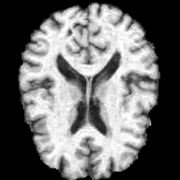

In [5]:
img_id = 101
arr_uint8 = (img_paths[img_id] * 255).clip(0, 255).astype(np.uint8)

# Step 2: Convert to PIL grayscale image
img = Image.fromarray(arr_uint8, mode='L')
label = imglabel[img_id].unsqueeze(0)
print(label)
img

In [6]:
# Load DSCM

import sys
sys.path.append("/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark")
sys.path.append("/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/methods/deepscm")
import torch
import numpy as np
from typing import Dict, List
from json import load
from importlib import import_module
from model import SCM
from tqdm import tqdm
import torch.nn as nn
from torch.utils.data import Dataset
import os
import numpy as np
import argparse
import random


from models.classifiers.classifier import Classifier
from models.classifiers.celeba_classifier import CelebaClassifier
from models.classifiers.celeba_complex_classifier import CelebaComplexClassifier
from models.classifiers.adni_classifier import ADNIClassifier
from ctf_datasets.morphomnist.dataset import MorphoMNISTLike
from ctf_datasets.celeba.dataset import Celeba
from ctf_datasets.adni.dataset import ADNI
from ctf_datasets.transforms import ReturnDictTransform, get_attribute_ids

from evaluation.metrics.composition import composition
from evaluation.metrics.minimality import minimality
from evaluation.embeddings.embeddings import get_embedding_model, get_embedding_fn
from evaluation.metrics.fid import fid
from evaluation.metrics.effectiveness import effectiveness
from evaluation.metrics.utils import save_selected_images, save_plots
from ctf_datasets.morphomnist.dataset import unnormalize as unnormalize_morphomnist
from ctf_datasets.celeba.dataset import unnormalize as unnormalize_celeba
from ctf_datasets.adni.dataset import unnormalize as unnormalize_adni

torch.multiprocessing.set_sharing_strategy('file_system')

rng = np.random.default_rng()

dataclass_mapping = {
    "morphomnist": (MorphoMNISTLike, unnormalize_morphomnist),
    "celeba": (Celeba, unnormalize_celeba),
    "adni": (ADNI, unnormalize_adni)
}


In [7]:
config = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/methods/deepscm/configs/adni/vae.json'
with open(config, 'r') as f:
    config = load(f)

dataset = config["dataset"]
attribute_size = config["attribute_size"]

models = {}
for variable in config["causal_graph"].keys():
    if variable not in config["mechanism_models"]:
        continue
    model_config = config["mechanism_models"][variable]

    module = import_module(model_config["module"])
    model_class = getattr(module, model_config["model_class"])
    model = model_class(params=model_config["params"], attr_size=attribute_size)

    models[variable] = model
    if "finetune" in model_config["params"] and model_config["params"]["finetune"] == 1:
        model.name += '_finetuned'

batch_size = config["mechanism_models"]["image"]["params"]["batch_size_val"]

scm = SCM(checkpoint_dir=config["checkpoint_dir"],
            graph_structure=config["causal_graph"],
            temperature=0.1,
            **models)

dataset = config["dataset"]
data_class, unnormalize_fn = dataclass_mapping[dataset]

transform = ReturnDictTransform(attribute_size)
test_set = data_class(attribute_size, split='test', transform=transform)

brain_vol_flow-epoch=22.ckpt
vent_vol_flow-epoch=17-v4.ckpt
image_vae-epoch=18.ckpt


/home/jovyan/fcvm-data-volume/kzzr229/workspace/counterfactual-benchmark/counterfactual_benchmark/methods/deepscm/model.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  

100%|██████████| 50/50 [00:02<00:00, 20.96it/s]


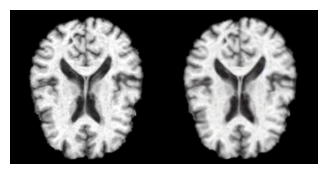

In [6]:
image=img
if not image.mode == "RGB":
    image = image.convert("RGB")

original_img = image.copy()
original_img = original_transforms(original_img)
condition_image = image.copy()
image = image_transforms(image) 

set_guidance_scale  = 1.0
num_steps = 50
s_step = 0
final_im,inverted_latents,_,_ = ddim_editing(pipe, image.unsqueeze(0),label.clone(),prompt,num_steps = num_steps,invert_guidance_scale=1.0,set_guidance_scale  = set_guidance_scale,intervention_indx=None,intervention_values=None,return_PIL=True)
        
to_pil =  transforms.ToPILImage()
save_images_grid([[original_img, final_im[0]]],(1,2),None)

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def plot_results(interved_images, direct_effects, titles=None,threshold=5.0):
    """
    Plot original/intervention images and corresponding direct effects.
    Parameters:
        interved_images (list of PIL.Image): List of images to display in row 1.
        direct_effects (list of np.ndarray): List of direct effect arrays for row 2.
        titles (list of str): Optional titles for row 1.
    """
    n_cols = len(interved_images)
    fig, axes = plt.subplots(2, n_cols, figsize=(4 * n_cols, 8))

    if titles is None:
        titles = ["Image {}".format(i) for i in range(n_cols)]

    # Row 1: Images
    for i, img in enumerate(interved_images):
        axes[0, i].imshow(np.array(img), cmap="gray")
        axes[0, i].axis("off")
        axes[0, i].set_title(titles[i], fontsize=12)

    # Row 2: Direct Effects
    for i, img in enumerate(direct_effects):
        if img is not None:
            lim = np.abs(img).max()
            lim = np.abs(img).max()
            if lim == 0:
                lim = 1e-6  # avoid vmin = vmax = 0
            effect = img.copy()
            effect[np.abs(effect) < threshold] = 0.0
            axes[1, i].imshow(effect, cmap='RdBu', vmin=-lim, vmax=lim)
            #axes[1, i].imshow(img, cmap='turbo', vmin=-lim, vmax=lim)
        axes[1, i].axis("off")
        axes[1, i].set_title("Direct Effect", fontsize=12)

    plt.tight_layout()
    plt.show()

def direct_effect(inter_img, ori_img):
    """
    Compute the pixel-wise direct effect between two PIL images (as grayscale arrays).
    """
    if not isinstance(inter_img, Image.Image):
        inter_img = Image.fromarray(inter_img)
    if not isinstance(ori_img, Image.Image):
        ori_img = Image.fromarray(ori_img)

    # Convert to grayscale and float32 numpy arrays
    array1 = np.array(inter_img.convert("L"), dtype=np.float32)
    array2 = np.array(ori_img.convert("L"), dtype=np.float32)

    # Compute pixel-wise difference
    effect =array1 - array2

    
    return effect


100%|██████████| 50/50 [00:02<00:00, 17.44it/s]


original label: tensor([[0.0000, 1.0000, 0.5848, 0.0000, 0.4660, 0.1607, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]])
tensor([[1.0000, 0.0000, 0.5848, 0.0000, 0.3431, 0.2328, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.7682, 0.0000, 0.3191, 0.3233, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.5848, 0.4152, 0.4332, 0.2328, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.5848, 0.0000, 0.0885, 0.2209, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.5848, 0.0000, 0.4660, 0.1320, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 1.0000, 0.5848, 0.0000, 0.4660, 0.1607, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0

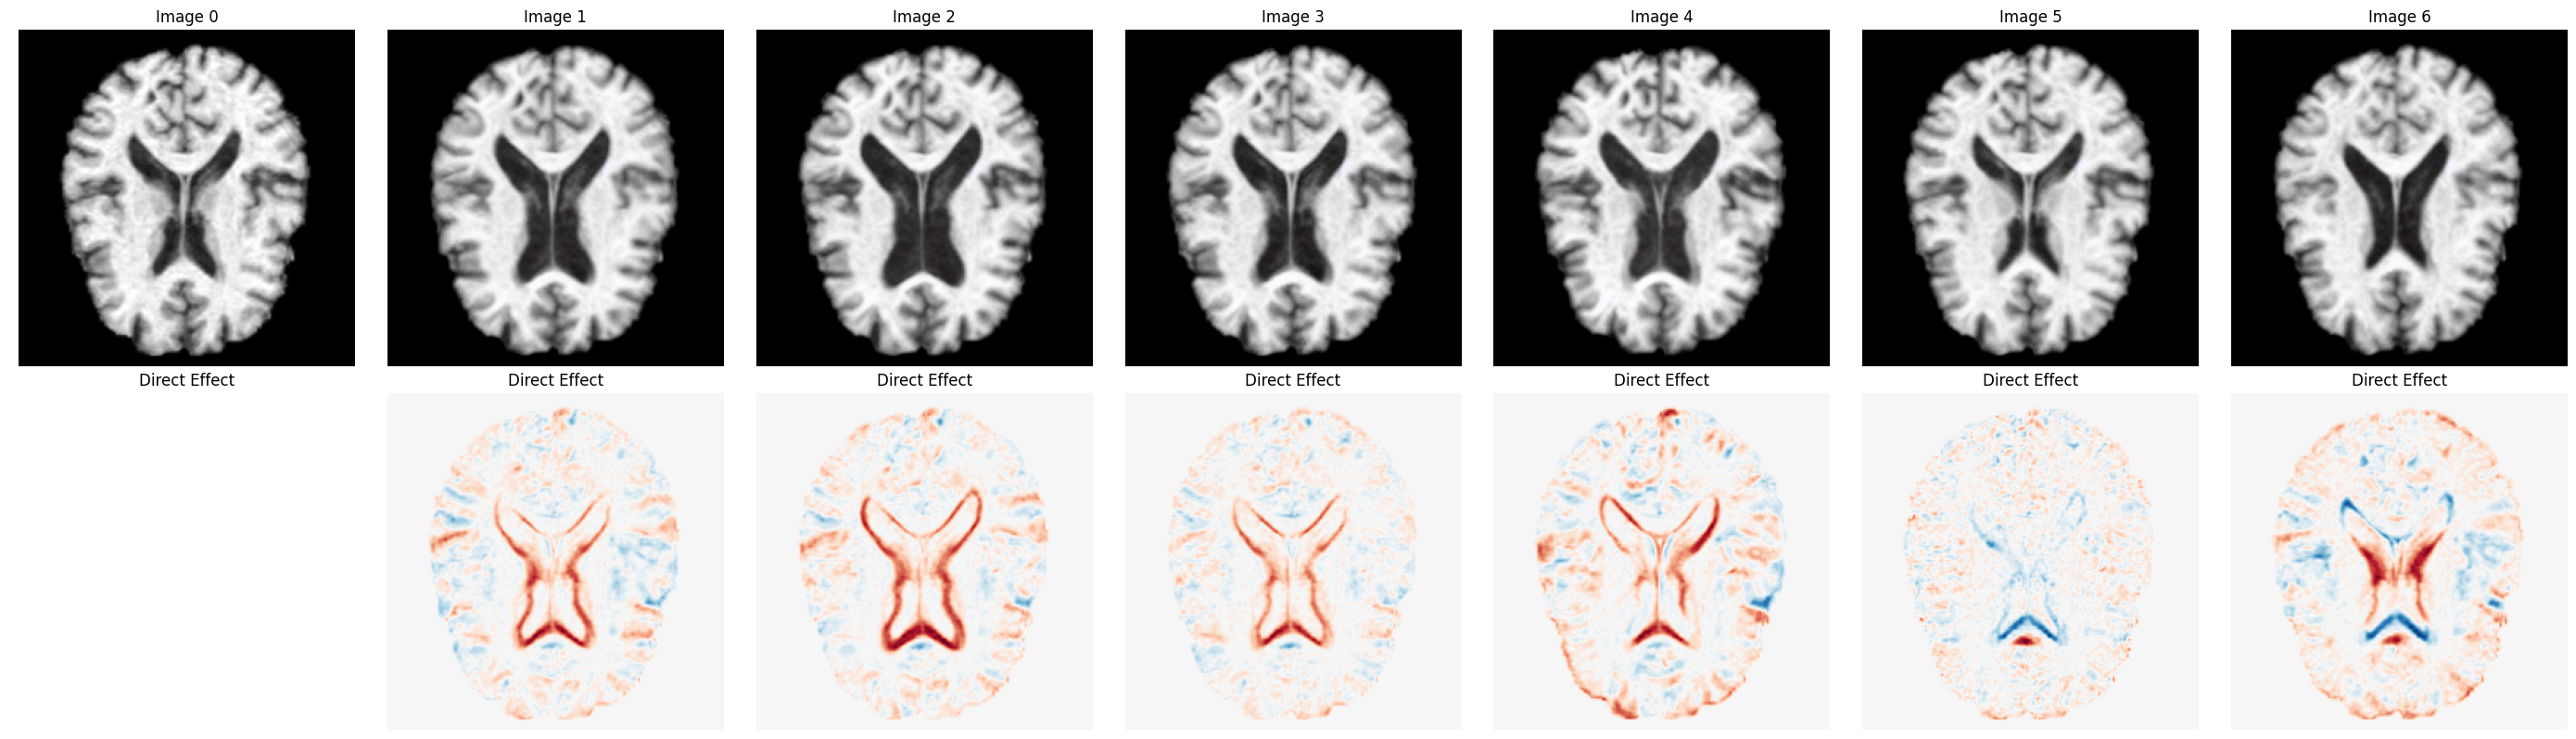

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt
from causal_modules.control_heads.ADNI import bin_array,ordinal_array
# Compute 1 - label for binary intervention (assuming label is tensor)

# Store original image and edited versions
image_lists = [original_img]
residual_maps = [None]
causal_cond_list = []
for inter_id in range(0, 6, 1):
    s_step = 0
    if inter_id == 0:
        # Sample from [0, 1, 2]
        intervention_values = torch.randint(0, 3, (label.shape[0],), device=label.device)
        inter_value = bin_array(intervention_values, m=2, reverse=False)

    elif inter_id == 2:
        # Complement binary label at index 2
        inter_value = 1 - label[:, 2]

    elif inter_id == 5:
        # Sample from [1, 10]
        intervention_values = torch.randint(1, 11, (label.shape[0],), device=label.device)
        inter_value = ordinal_array(intervention_values, m=10, reverse=False)

    else:
        # Sample from continuous uniform (0, 1)
        inter_value = torch.rand(label.shape[0], device=label.device)


    interved_image, causal_cond = sample(
        pipe,
        prompt,
        start_step=s_step,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=1.0,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=inter_id,
        intervention_values=inter_value,
        label=label.clone(),
        return_PIL=True
    )
    #print(f"Intervention {inter_id}: {causal_cond}")
    causal_cond_list.append(causal_cond.squeeze(2))
    edited_image_np = interved_image[0]
    image_lists.append(edited_image_np)

    # Compute residual map
    residual = direct_effect(edited_image_np,original_img)
    residual_maps.append(residual)
print('original label:',label)
print(torch.cat(causal_cond_list,dim=0))
# Save all images in a grid: original + 6 interventions
plot_results(image_lists,residual_maps)

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:02<00:00, 20.77it/s]


save imgs in ./intervention_variable1.png


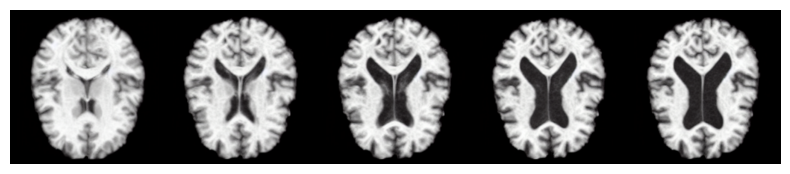

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from causal_modules.control_heads.ADNI import bin_array,ordinal_array
# Compute 1 - label for binary intervention (assuming label is tensor)
range_len=5
inter_value = torch.from_numpy(np.linspace(0, 0.6, num=range_len))
# Store original image and edited versions
image_lists = []
residual_maps = [None]
causal_cond_list = []
for i in range(0, range_len, 1):
    interved_image, causal_cond = sample(
        pipe,
        prompt,
        start_step=s_step,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=1.0,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=4,
        intervention_values=inter_value[i],
        label=label.clone(),
        return_PIL=True
    )
    #print(f"Intervention {inter_id}: {causal_cond}")
    causal_cond_list.append(causal_cond.squeeze(2))
    edited_image_np = interved_image[0]
    image_lists.append(edited_image_np)


output='./'
save_path = os.path.join(output,'intervention_variable{}.png'.format(1))
save_images_grid([image_lists],(1,range_len),save_path)
print('save imgs in {}'.format(save_path))

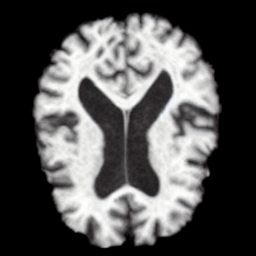

In [10]:
image_lists[4]

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:03<00:00, 14.61it/s]


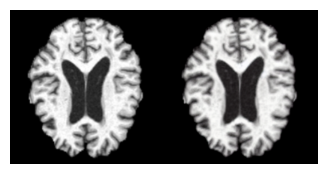

In [12]:
interved_image,causal_cond = sample(
        pipe,
        prompt,
        start_step=s_step,
        start_latents=inverted_latents[-(s_step + 1)].clone(),
        guidance_scale=1.0,
        num_inference_steps=num_steps,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=3,
        intervention_values=1,
        label=label.clone(),
        return_PIL = True
)

save_images_grid([[original_img, final_im[0]]],(1,2),None)

# P2P

50it [00:05,  9.99it/s]


ID3,:tensor([0.4963])


50it [00:05,  9.98it/s]


ID4,:tensor([0.4963])


50it [00:05,  9.99it/s]


ID5,:tensor([[0., 0., 0., 0., 0., 1., 1., 1., 1., 1.]])
original label: tensor([[0.0000, 1.0000, 0.5848, 0.0000, 0.4660, 0.1607, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.0000]])


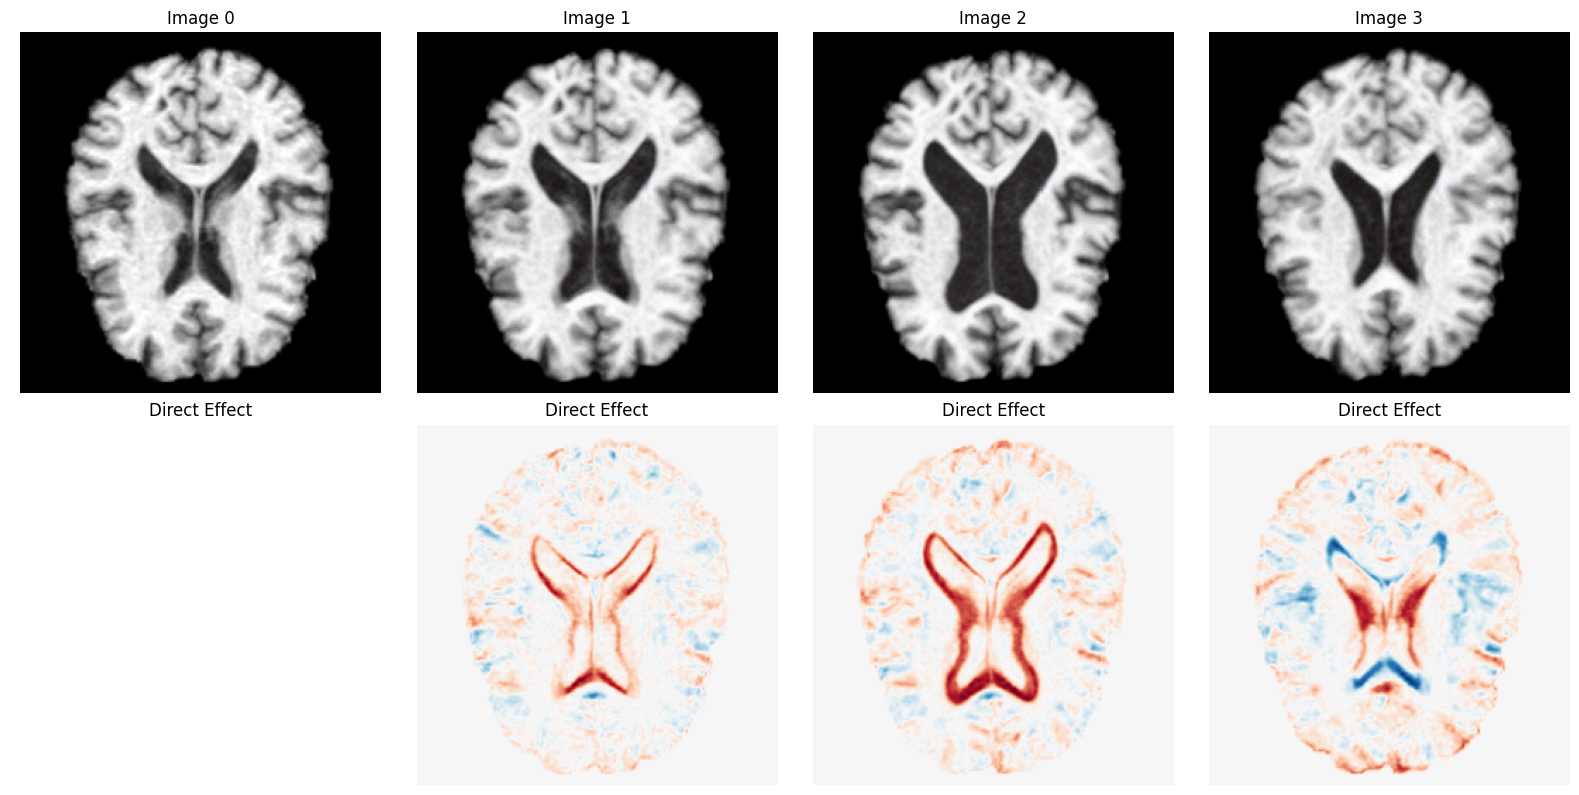

: 

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from causal_modules.control_heads.ADNI import bin_array,ordinal_array
# Compute 1 - label for binary intervention (assuming label is tensor)



# backup_pipe = deepcopy(pipe)
set_guidance_scale  = 1.0
num_steps = 50      
s_step = 0
invert_guidance_scale=1.0
# False use the normal DDIM 
blend_word = True
# start_blend=0.2, th=(.3, .3)
image_lists = [original_img]
residual_maps = [None]
causal_cond_list = []


for inter_id in range(3, 6, 1):
    s_step = 0
    if inter_id == 0:
        # Sample from [0, 1, 2]
        intervention_values = torch.randint(0, 3, (label.shape[0],), device=label.device)
        inter_value = bin_array(intervention_values, m=2, reverse=False)

    elif inter_id == 2:
        # Complement binary label at index 2
        inter_value = 1 - label[:, 2]

    elif inter_id == 5:
        # Sample from [1, 10]
        intervention_values = torch.randint(1, 11, (label.shape[0],), device=label.device)
        inter_value = ordinal_array(intervention_values, m=10, reverse=False)

    else:
        # Sample from continuous uniform (0, 1)
        inter_value = torch.rand(label.shape[0], device=label.device)


    blend_params = {'start_blend':0.0,'th':(0.3,0.3)}
    cross_replace_steps,self_replace_steps = 0.0,0.0

    interved_image,inverted_latents,_,uncond_embeddings = P2P_editing(pipe, image.unsqueeze(0),
                                                        label.clone(),prompt,presudo_list,
                                                        num_steps = num_steps,invert_guidance_scale=invert_guidance_scale,
                                                        set_guidance_scale  = set_guidance_scale,intervention_indx=inter_id,
                                                        intervention_values=inter_value,return_PIL=True,
                                                        blend_word=blend_word,blend_params=blend_params,
                                                        disentangle=False,
                                                        cross_replace_steps=cross_replace_steps,self_replace_steps=self_replace_steps,)
    image_lists.append(interved_image[-1])
    print(f'ID{inter_id},:{inter_value}')
    residual = direct_effect(interved_image[-1],original_img)
    residual_maps.append(residual)
print('original label:',label)
# Save all images in a grid: original + 6 interventions
plot_results(image_lists,residual_maps)



In [1]:
import torch
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import os
import cv2

def find_top5_image_ids_batch(data, selected_img_dir, device='cuda'):
    # 加载所有要比对的输入图片
    selected_imgs = []
    img_names = []
    
    transform_input = transforms.Compose([
        transforms.Resize((64, 64)),    # Resize到64x64
        transforms.ToTensor(),          # (C,H,W)，范围[0,1]
    ])
    
    for img_name in sorted(os.listdir(selected_img_dir)):
        img_path = os.path.join(selected_img_dir, img_name)
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: Cannot read image {img_path}, skip.")
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        input_img = Image.fromarray(img)
        input_tensor = transform_input(input_img)
        selected_imgs.append(input_tensor)
        img_names.append(img_name)
    print(img_names)
    # 把选中图片堆成一个 batch
    input_batch = torch.stack(selected_imgs).to(device)  # (N,C,H,W)

    # 加载CelebA所有图，统一处理成 batch
    celebA_tensors = []
    transform_celeba = transforms.Compose([
        transforms.CenterCrop(150),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
    ])
    
    for idx in tqdm(range(len(data)), desc="Loading CelebA"):
        celebA_img, _ = data[idx]
        celebA_img = transform_celeba(celebA_img)
        celebA_tensors.append(celebA_img)
    
    celebA_batch = torch.stack(celebA_tensors).to(device)  # (M,C,H,W)

    # 计算每一张输入图片到CelebA所有图的距离
    results = {}
    for i, input_tensor in enumerate(input_batch):
        input_expand = input_tensor.unsqueeze(0).expand(celebA_batch.size(0), -1, -1, -1)
        diff = celebA_batch - input_expand  # (M,C,H,W)
        dists = (diff ** 2).sum(dim=(1,2,3)).sqrt()  # 正确地计算batch-wise L2距离
        top5_dist, top5_idx = torch.topk(dists, k=5, largest=False)

        results[img_names[i]] = list(zip(top5_idx.tolist(), top5_dist.tolist()))
    
    return results

selected_img_dir = "/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/celeA_selected_images/"
results = find_top5_image_ids_batch(data, selected_img_dir)

for img_name, top5 in results.items():
    print(f"\nImage: {img_name}")
    for rank, (idx, dist) in enumerate(top5):
        print(f"  Top-{rank+1}: Image ID {idx}, Distance {dist:.4f}")


NameError: name 'data' is not defined

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:03<00:00, 14.87it/s]


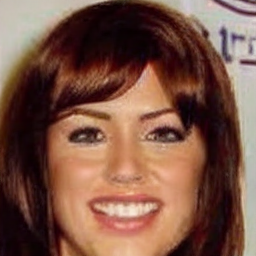

In [ ]:
# try replace word
#prompt =  'orange @ and red * and black & and black !'
new_prompt = 'a human of @ and * and & and !'
input_ids = tokenizer(new_prompt,
                        padding="max_length",
                        truncation=True,
                        max_length=tokenizer.model_max_length,
                        return_tensors="pt",
                    ).input_ids[0].to(device)

if input_ids.dim() ==1:
    input_ids=input_ids.unsqueeze(0)

start_latents = torch.randn(1, 4, 32, 32, device=device)
start_latents *= pipe.scheduler.init_noise_sigma
final_im = sample(
        pipe,
        new_prompt,
        start_step=0,
        start_latents=start_latents,
        #start_latents=inverted_latents[-(0 + 1)][None],
        guidance_scale=7.5,
        num_inference_steps=50,
        num_images_per_prompt=1,
        negative_prompt=None,
        device=device,
        controlnet_image=None,
        intervention_indx=None,
        intervention_values=None,
        label=torch.tensor([0,0,1,0],dtype=torch.float32).unsqueeze(0),
        return_PIL=True
    )[0]

final_im

# Plot Attn Maps

In [15]:
import os
prompts = [prompt]
out_base = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/outputs/attention_maps/'
exp_name = 'textcond'
if not os.path.exists(out_base):
    os.mkdir(out_base) 
out_path_base = os.path.join(out_base, exp_name)
if not os.path.exists(out_path_base):
    os.mkdir(out_path_base) 
out_path_prompt = os.path.join(out_path_base, prompts[0])
if not os.path.exists(out_path_prompt):
    os.mkdir(out_path_prompt)
out_dir = out_path_prompt
out_name = 'causalnet'+'.png'

ax shape: (1, 7)


100%|██████████| 49/49 [00:02<00:00, 17.81it/s]


  0%|          | 0/50 [00:00<?, ?it/s]

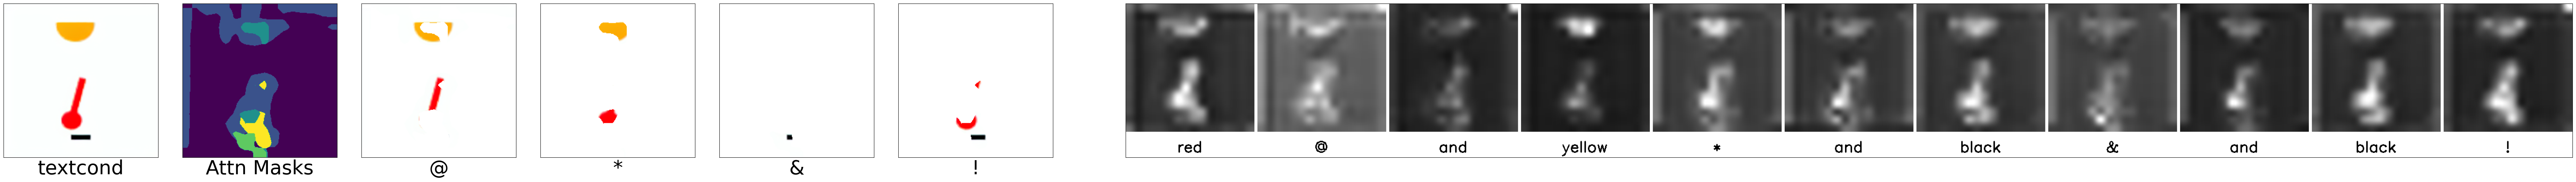

<Figure size 640x480 with 0 Axes>

In [17]:
import sys
sys.path.append('/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser')
from scripts.show_attn_maps import ptp_tools,ptp_utils
import importlib
importlib.reload(ptp_tools)
importlib.reload(ptp_utils)
attn_threshold = 0.5

# pipe = StableDiffusionCausalControlNetPipeline.from_pretrained(
#     base_model_path, controlnet=controlnet,text_encoder=text_encoder ,torch_dtype=torch.float32
# )
# pipe.scheduler = DDIMScheduler.from_config(
#     pipe.scheduler.config
# )
# pipe.safety_checker = None
# pipe.requires_safety_checker = False
# #pipe.load_mcpl_inversion(mcpl_embedding_path)


# # memory optimization.
# #pipe.enable_model_cpu_offload()
# pipe = pipe.to(device)

ptp_tools.plot_img_attn_mask_textcontrol(pipe, prompts,presudo_words,condition_image, \
        device, out_dir, out_name, latent=img_latent,res=16,label=label, \
        GUIDANCE_SCALE=1,attn_threshold=attn_threshold, only_sampling=False,\
        intervention_indx=None,intervention_values=None,from_where=['down','up'],mask_concepts=True, g_gpu=generator,num_steps=50,img_size=size,exp_names=[exp_name])

In [ ]:
import torch
from torch.nn import functional as F
def kl_normal(qm, qv, pm, pv):
    """
    Computes the elem-wise KL divergence between two normal distributions KL(q || p) and
    sum over the last dimension

    Args:
        qm: tensor: (batch, dim): q mean
        qv: tensor: (batch, dim): q variance
        pm: tensor: (batch, dim): p mean
        pv: tensor: (batch, dim): p variance

    Return:
        kl: tensor: (batch,): kl between each sample
    """
    element_wise = 0.5 * (torch.log(pv) - torch.log(qv) + qv / pv + (qm - pm).pow(2) / pv - 1)
    print(element_wise)
    kl = element_wise.sum(-1)

    return kl

q_m = torch.tensor([[2.0,3.0,3.0,5.0],[2.0,3.0,3.0,5.0]])
p_m  = torch.tensor([[0.0,0.0,1.0,2.5],[0.0,0.0,1.0,2.5]])
print(kl_normal(q_m,torch.ones((q_m.shape)),p_m,torch.ones((q_m.shape))))
print(0.5*F.mse_loss(q_m,p_m,reduction='sum'))

tensor([[2.0000, 4.5000, 2.0000, 3.1250],
        [2.0000, 4.5000, 2.0000, 3.1250]])
tensor([11.6250, 11.6250])
tensor(23.2500)


In [ ]:
def dataset_load_path(data_root='/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test'):
    # name like sampling_100 , sampling_500 dir
    image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
    label_list = [list(map(int,k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]
    scale = np.array([[0,44],[100,40],[6.5, 3.5],[10,5]])
    img_id = random.randint(0,len(image_paths))
    print(image_paths[img_id])
    print(label_list[img_id])

    
    label = torch.from_numpy(np.asarray(label_list[img_id]))
    array1 = np.asarray(label).astype(np.float32)
    label = torch.from_numpy(array1)
    norm_label = torch.zeros(label.shape)        
    for i in range(label.shape[0]):
        norm_label[i] = (label[i] - scale[i][0]) / scale[i][1]
    print('norm label',norm_label)
    
    return image_paths[img_id],norm_label

data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/train'
image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
label_list1 = [list(map(int, k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]

# Load test labels
data_root = '/home/jovyan/fcvm-data-volume/kzzr229/workspace/MCPL-diffuser/dataset/causal_data/pendulum/test'
image_paths = [os.path.join(data_root, file_path) for file_path in os.listdir(data_root)]
label_list2 = [list(map(int, k[:-4].split("/")[-1].split('_')[1:])) for k in image_paths]

# Concatenate label lists
all_labels = np.array(label_list1 + label_list2)

# Compute column-wise min and max
col_min = all_labels.min(axis=0)
col_max = all_labels.max(axis=0)

print("Column-wise min values:", col_min)
print("Column-wise max values:", col_max)



Column-wise min values: [-40  60   3   2]
Column-wise max values: [ 43 147  12  19]


In [26]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

A = torch.tensor([
    [0, 1, 0, 0],
    [0, 0, 1, 1],
    [0, 0, 0, 0],
    [0, 0, 0, 0]
], dtype=torch.float32).to(device)

def get_reason_and_result_variable_indices(A):
    reason_variable_indices = []
    result_variable_indices = []

    for i in range(A.size(1)):
        col = A[:, i]

        if torch.all(col == 0):
            reason_variable_indices.append(i)
        if torch.any(col != 0):
            result_variable_indices.append(i)
    
    return reason_variable_indices, result_variable_indices

reason_v_indices, result_v_indices = get_reason_and_result_variable_indices(A)
print("Reason variable indices:", reason_v_indices)
print("Result variable indices:", result_v_indices)


Reason variable indices: [0]
Result variable indices: [1, 2, 3]
